In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyArrowPatch


In [2]:

# ============================================================
# 1) Smooth spline helper (Catmull–Rom, easy + stable, no SciPy)
# ============================================================


def _dedupe_consecutive(P, eps=1e-9):
    """Remove consecutive duplicate (or nearly duplicate) control points."""
    P = np.asarray(P, float)
    if len(P) == 0:
        return P
    out = [P[0]]
    for i in range(1, len(P)):
        if np.linalg.norm(P[i] - out[-1]) > eps:
            out.append(P[i])
    return np.asarray(out, float)

def catmull_rom_spline(P, n_per_seg=40, alpha=0.5, closed=False, eps=1e-9):
    """
    Robust Catmull–Rom spline.
    - removes consecutive duplicates
    - protects against zero-length segments (eps)
    """
    P = _dedupe_consecutive(P, eps=eps)
    if P.shape[0] < 2:
        return P

    if closed:
        pts = np.vstack([P[-1], P, P[0], P[1]])
    else:
        pts = np.vstack([P[0], P, P[-1]])

    def tj(ti, pi, pj):
        d = np.linalg.norm(pj - pi)
        d = max(d, eps)
        return ti + (d ** alpha)

    out = []
    for i in range(1, len(pts) - 2):
        p0, p1, p2, p3 = pts[i-1], pts[i], pts[i+1], pts[i+2]
        t0 = 0.0
        t1 = tj(t0, p0, p1)
        t2 = tj(t1, p1, p2)
        t3 = tj(t2, p2, p3)

        # If still degenerate, skip safely
        if (t1 - t0) < eps or (t2 - t1) < eps or (t3 - t2) < eps:
            continue

        t = np.linspace(t1, t2, n_per_seg)

        def safe_div(num, den):
            den = np.where(np.abs(den) < eps, eps*np.sign(den + eps), den)
            return num / den

        A1 = safe_div((t1 - t)[:, None], (t1 - t0)) * p0 + safe_div((t - t0)[:, None], (t1 - t0)) * p1
        A2 = safe_div((t2 - t)[:, None], (t2 - t1)) * p1 + safe_div((t - t1)[:, None], (t2 - t1)) * p2
        A3 = safe_div((t3 - t)[:, None], (t3 - t2)) * p2 + safe_div((t - t2)[:, None], (t3 - t2)) * p3

        B1 = safe_div((t2 - t)[:, None], (t2 - t0)) * A1 + safe_div((t - t0)[:, None], (t2 - t0)) * A2
        B2 = safe_div((t3 - t)[:, None], (t3 - t1)) * A2 + safe_div((t - t1)[:, None], (t3 - t1)) * A3

        C  = safe_div((t2 - t)[:, None], (t2 - t1)) * B1 + safe_div((t - t1)[:, None], (t2 - t1)) * B2

        out.append(C)

    if not out:
        # fallback: just return straight polyline if spline fails
        return P

    return np.vstack(out)

def sample_spline_xy(xy, n=600):
    xy = _dedupe_consecutive(xy)
    if len(xy) < 2:
        xy = np.asarray(xy, float)
        return xy[:,0], xy[:,1]
    n_per = max(10, n // max(1, (len(xy)-1)))
    pts = catmull_rom_spline(xy, n_per_seg=n_per)
    # remove any NaNs defensively
    pts = pts[np.isfinite(pts).all(axis=1)]
    return pts[:, 0], pts[:, 1]




In [3]:
# ============================================================
# 2) Drawing primitives: curve, arrow, band with variable width
# ============================================================
def draw_curve(ax, xy_ctrl, *,
               n=700, color="k", lw=3, ls="-", alpha=1.0, z=5,
               clip_ymin=None):
    x, y = sample_spline_xy(xy_ctrl, n=n)
    if clip_ymin is not None:
        y = np.maximum(y, clip_ymin)
    ax.plot(x, y, color=color, lw=lw, ls=ls, alpha=alpha, zorder=z)
    return x, y

def draw_arrow(ax, xy0, xy1, *, color="k", lw=3, ms=25, z=10):
    ax.add_patch(FancyArrowPatch(
        xy0, xy1,
        arrowstyle='-|>',
        mutation_scale=ms,
        linewidth=lw,
        color=color,
        zorder=z
    ))

def _interp_w_along_x(x_dense, xw, ww):
    # width control points given vs x; interpolate width on dense x grid
    xw = np.asarray(xw, float)
    ww = np.asarray(ww, float)
    idx = np.argsort(xw)
    xw, ww = xw[idx], ww[idx]
    return np.interp(x_dense, xw, ww)

def draw_band(ax, mid_xy_ctrl, w_x_ctrl, w_ctrl, *,
              n=900, face="#f6d27f", edge="none",
              alpha0=0.95, z=1,
              fade=None,   # None OR dict: {"x0":..., "x1":...}
              clip_ymin=None):
    """
    mid_xy_ctrl: control points for the band centerline (x,y).
    w_x_ctrl, w_ctrl: control points for half-width w(x).
    fade: if given, alpha fades from x0->x1 to 0.
    """
    x, y = sample_spline_xy(mid_xy_ctrl, n=n)

    w = _interp_w_along_x(x, w_x_ctrl, w_ctrl)

    ytop = y + w
    ybot = y - w

    if clip_ymin is not None:
        ybot = np.maximum(ybot, clip_ymin)

    # Gradient-ish fade by slicing in x
    if fade is None:
        pts = np.column_stack([np.r_[x, x[::-1]], np.r_[ytop, ybot[::-1]]])
        ax.add_patch(Polygon(pts, closed=True, facecolor=face, edgecolor=edge, alpha=alpha0, zorder=z))
        return x, y, w

    x0, x1 = fade["x0"], fade["x1"]
    # slice into quads
    for i in range(len(x)-1):
        xm = 0.5*(x[i] + x[i+1])
        if xm <= x0:
            a = alpha0
        elif xm >= x1:
            a = 0.0
        else:
            a = alpha0*(1.0 - (xm - x0)/(x1 - x0))
        if a <= 1e-3:
            continue
        a = float(a)
        if not np.isfinite(a):
            continue
        a = max(0.0, min(1.0, a))

        quad = np.array([
            [x[i],   ytop[i]],
            [x[i+1], ytop[i+1]],
            [x[i+1], ybot[i+1]],
            [x[i],   ybot[i]],
        ])
        ax.add_patch(Polygon(quad, closed=True, facecolor=face, edgecolor=edge, alpha=a, zorder=z))

    return x, y, w



In [4]:

# ============================================================
# 3) Your editable control points (YOU will tweak these by hand)
# ============================================================

Tc_y = 5.7
x_nuc, y_nuc = 5.0, 0.0

# ---- Phase Transition band (centerline + width-vs-x) ----
# Make FIRST point exactly (0, Tc_y)!
PT_MID_XY = [
    (0.0, Tc_y),
    (1.3, 5.45),
    (3.0, 5.10),
    (4.0, 4.60),
    (4.5, 4.1),
    (5.0, 3.05),
    (5.4, 2.),
    (5.8, 1.),
    (6.1, 0.125),
    (6.15, -1.0),
    (6.2, -2.0),
]

# Half-width control points (w(x)) — edit these to narrow/widen anywhere
PT_W_X   = [0.0, 1.0, 3.0, 4.5, 5.5, 6.2]
PT_W     = [0.10, 0.22, 0.38, 0.95, 1.62, 2.55]

# Fade: you can move these by hand too
PT_FADE = {"x0": 7.2, "x1": 9.4}   # start fading at x0, fully gone by x1

# ---- Chemical freeze-out (red dotted) ends at nuclei ----
CHEM_XY = [
    (0.0, Tc_y-0.25),
    (1.6, 5.45),
    (3.2, 5.10),
    (4.4, 4.55),
    (4.9, 2.40),
    (x_nuc, y_nuc),
]

# ---- Kinetic freeze-out (blue dotted) ends at nuclei ----
KIN_XY = [
    (0.0, 3.00),
    (2.0, 2.75),
    (3.8, 2.35),
    (4.7, 1.65),
    (x_nuc, y_nuc),
]

# ---- Red trajectory (optional) ----
TRAJ_XY = [
    (3.2, 9.2),
    (2.8, 8.2),
    (2.35, 6.8),
    (2.20, 5.2),
    (2.45, 3.5),
    (3.20, 1.1),
]


In [5]:

# ============================================================
# 4) Draw scene with configurable draw order
# ============================================================
def make_plot(draw_order=("axes", "blob", "pt_band", "freezeout", "traj", "labels")):
    fig = plt.figure(figsize=(12.6, 7.6))
    ax = fig.add_axes([0.04, 0.06, 0.92, 0.90])
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
    ax.axis("off")

    def draw_axes():
        ax.plot([-0.2, 10.0], [0, 0], color="k", lw=3, zorder=20)
        draw_arrow(ax, (10.0, 0), (10.35, 0), lw=3, ms=55, color="k", z=21)
        ax.plot([0, 0], [-0.2, 10.0], color="k", lw=3, zorder=20)
        draw_arrow(ax, (0, 10.0), (0, 10.35), lw=3, ms=55, color="k", z=21)

    def draw_blob():
        # simple neutron-star region blob (edit if you want)
        x2 = np.linspace(6.9, 10.35, 250)
        y2_top = 1.6 + 0.9*np.sin((x2-6.9)/(10.35-6.9)*np.pi/1.25)
        y2_top = np.clip(y2_top, 1.4, 2.9)
        pts = np.column_stack([np.r_[x2, x2[::-1]], np.r_[y2_top, np.zeros_like(x2)]])
        ax.add_patch(Polygon(pts, closed=True, facecolor="#ef9a8a", edgecolor="none", zorder=0, alpha=0.95))

    def draw_pt_band():
        draw_band(ax, PT_MID_XY, PT_W_X, PT_W,
                  face="#f6d27f", alpha0=0.95, z=2,
                  fade=PT_FADE, clip_ymin=0.0)

    def draw_freezeout():
        draw_curve(ax, CHEM_XY, color="red", lw=3, ls=":", z=6, clip_ymin=0.0)
        draw_curve(ax, KIN_XY, color="dodgerblue", lw=3, ls=":", z=6, clip_ymin=0.0)

    def draw_traj():
        draw_curve(ax, TRAJ_XY, color="red", lw=3, ls="-", z=8)
        ax.plot([TRAJ_XY[0][0]], [TRAJ_XY[0][1]], "o", ms=12, color="red", zorder=9)

    def draw_labels():
        ax.text(-0.35, 9.8, "Temperature", rotation=90, va="top", ha="center",
                fontsize=26, fontweight="bold")
        ax.text(7.5, -0.35, "Baryon Chemical Potential", va="top", ha="center",
                fontsize=22, fontweight="bold")
        ax.text(-0.2, -0.1, "0", fontsize=26, va="top", ha="right")

        ax.text(-0.1, Tc_y, r"$T_c$", fontsize=28, va="center", ha="right", fontweight="bold")
        ax.text(1.0, 9.6, "Quark Gluon Plasma", fontsize=28, fontweight="bold", ha="left")

        ax.plot([x_nuc], [y_nuc], "o", ms=10, color="k", zorder=30)
        ax.text(x_nuc+0.15, y_nuc+0.12, "Nuclei", fontsize=12, ha="left", va="bottom", fontweight="bold")

        ax.text(6.2, 3.2, "Phase Transition", rotation=-55, fontsize=20,
                fontweight="bold", ha="center", va="center", zorder=10)
        ax.text(8.9, 2.15, "Color\nSuperconductor", fontsize=24, fontweight="bold",
                ha="center", va="center")
        ax.text(9.0, 0.75, "Neutron Stars", fontsize=18, ha="center", va="center")
        ax.text(1.3, 1.2, "Hadron Gas", fontsize=14, fontweight="bold", ha="left")

    draw_map = {
        "axes": draw_axes,
        "blob": draw_blob,
        "pt_band": draw_pt_band,
        "freezeout": draw_freezeout,
        "traj": draw_traj,
        "labels": draw_labels,
    }

    for key in draw_order:
        draw_map[key]()

    return fig, ax



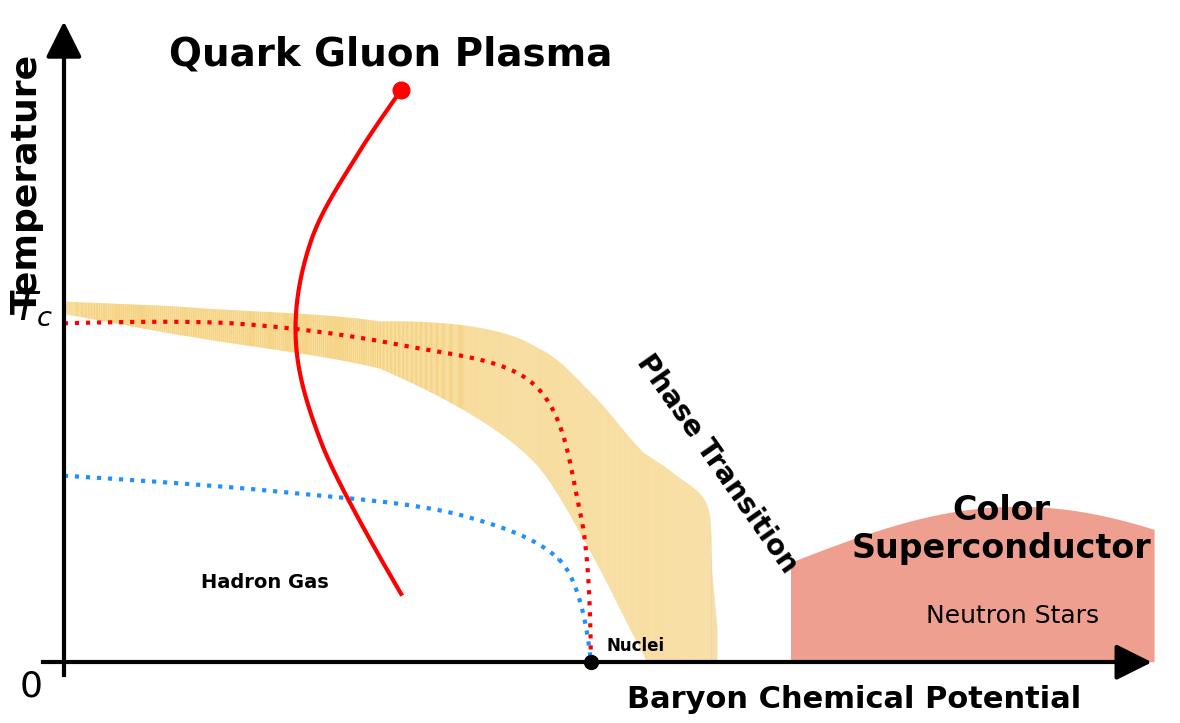

In [6]:

# ---------------- run ----------------
if __name__ == "__main__":
    make_plot(draw_order=("blob", "pt_band", "freezeout", "traj", "axes", "labels"))
    plt.show()


Welcome to JupyROOT 6.30/06


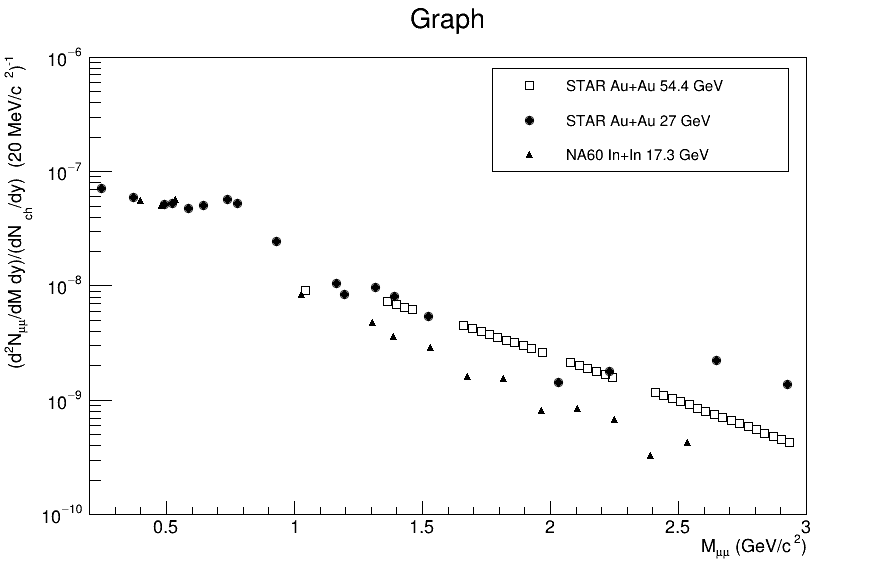

In [7]:
import pandas as pd
import ROOT as R

def load_tgraph(csv, marker, msize=1.0):
    df = pd.read_csv(csv)
    g = R.TGraph(len(df))
    for i,(x,y) in enumerate(zip(df["M_GeV"], df["y"])):
        g.SetPoint(i, float(x), float(y))
    g.SetMarkerStyle(marker)
    g.SetMarkerSize(msize)
    return g

g_red = load_tgraph("input/star54p4_red_digitized.csv", 25, 1.0)   # open square-ish
g_blk = load_tgraph("input/star27_black_digitized.csv", 20, 1.0)   # filled circle
g_mag = load_tgraph("input/na60_magenta_digitized_v2.csv", 22, 1.0)# triangle

c = R.TCanvas("c","c",900,600)
c.SetLogy()

g_red.Draw("AP")
g_red.GetXaxis().SetTitle("M_{#mu#mu} (GeV/c^{2})")
g_red.GetYaxis().SetTitle("(d^{2}N_{#mu#mu}/dM dy)/(dN_{ch}/dy)  (20 MeV/c^{2})^{-1}")
g_red.GetYaxis().SetRangeUser(1e-10, 1e-6)
g_red.GetXaxis().SetLimits(0.2, 3.0)

g_blk.Draw("P SAME")
g_mag.Draw("P SAME")

leg = R.TLegend(0.55,0.70,0.88,0.88)
leg.AddEntry(g_red,"STAR Au+Au 54.4 GeV","p")
leg.AddEntry(g_blk,"STAR Au+Au 27 GeV","p")
leg.AddEntry(g_mag,"NA60 In+In 17.3 GeV","p")
leg.Draw()

c.Draw()


****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      1.65913
NDf                       =            8
Edm                       =   6.3796e-06
NCalls                    =          204
p0                        =  2.48381e-06   +/-   2.11688e-06 
p1                        =     0.256957   +/-   0.0332651   


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


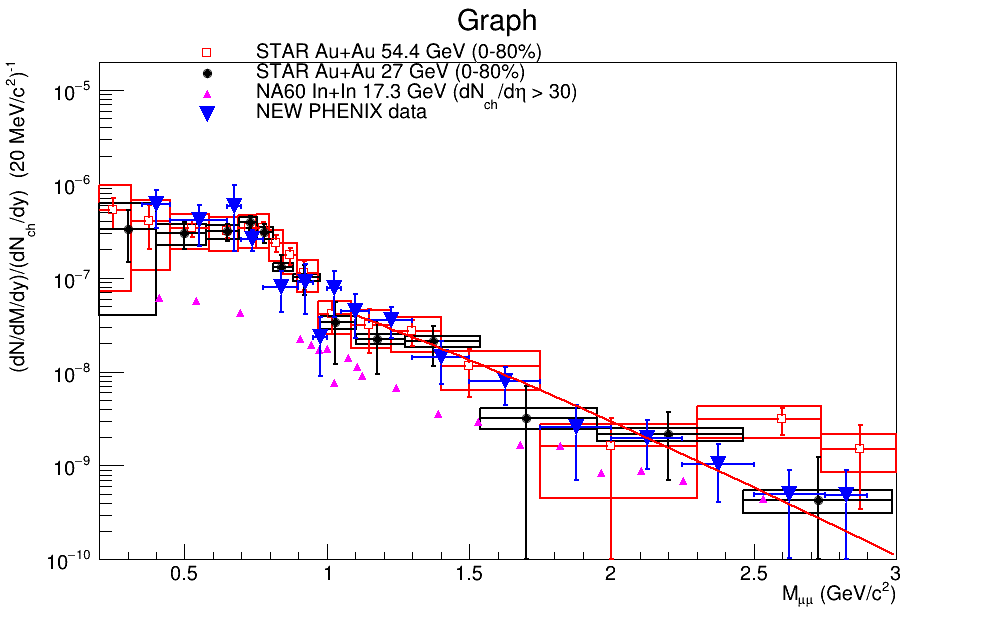

In [8]:
import numpy as np
import pandas as pd
import ROOT as R
from array import array

# --- inputs ---
f_star27 = "input/HEPData-ins2755369-v1-Table_3.csv"
f_star54 = "input/HEPData-ins2755369-v1-Table_4.csv"
f_na60   = "input/na60_magenta_digitized.csv"

df27 = pd.read_csv(f_star27, comment="#")
df54 = pd.read_csv(f_star54, comment="#")
dfN  = pd.read_csv(f_na60)

# HEPData column names (your tables)
cx = "M_{ll} [GeV/c^{2}]"
cy = "(dN/dM/dy)/(dNch/dy) [(20 MeV/c^{2})^{-1}]"

def find_xedge_cols(df, xname):
    """Try common HEPData edge column patterns."""
    candidates = [
        (f"{xname} low", f"{xname} high"),
        (f"{xname} LOW", f"{xname} HIGH"),
        (f"{xname} [LOW]", f"{xname} [HIGH]"),
        (f"{xname} (low)", f"{xname} (high)"),
        (f"{xname} lower", f"{xname} upper"),
        (f"{xname} min", f"{xname} max"),
    ]
    cols = {c.lower(): c for c in df.columns}
    for a,b in candidates:
        if a.lower() in cols and b.lower() in cols:
            return cols[a.lower()], cols[b.lower()]
    return None, None

def infer_edges_from_centers(x):
    """
    Fallback: infer bin edges from centers using midpoints between adjacent centers.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    edges = np.zeros(n+1, dtype=float)
    mids = 0.5*(x[1:] + x[:-1])
    edges[1:-1] = mids
    edges[0] = x[0] - (mids[0] - x[0])
    edges[-1] = x[-1] + (x[-1] - mids[-1])
    return edges

def get_xerrs(df, xname):
    x = df[xname].astype(float).to_numpy()
    xlo_col, xhi_col = find_xedge_cols(df, xname)
    if xlo_col is not None:
        xlo = df[xlo_col].astype(float).to_numpy()
        xhi = df[xhi_col].astype(float).to_numpy()
        exl = x - xlo
        exh = xhi - x
        return x, exl, exh
    # fallback: infer edges from centers
    edges = infer_edges_from_centers(x)
    xlo = edges[:-1]
    xhi = edges[1:]
    exl = x - xlo
    exh = xhi - x
    return x, exl, exh

def make_star_graphs(df, marker_style, marker_size, color):
    """
    Returns (g_stat, g_syst) as TGraphAsymmErrors with x-errors = half-bin width.
    """
    x, exl, exh = get_xerrs(df, cx)

    n = len(df)
    g_stat = R.TGraphAsymmErrors(n)
    g_syst = R.TGraphAsymmErrors(n)

    for i in range(n):
        xi = float(x[i])
        yi = float(df.loc[i, cy])

        es_hi = float(df.loc[i, "stat +"])
        es_lo = abs(float(df.loc[i, "stat -"]))
        ey_hi = float(df.loc[i, "syst +"])
        ey_lo = abs(float(df.loc[i, "syst -"]))

        g_stat.SetPoint(i, xi, yi)
        g_stat.SetPointError(i, float(exl[i]), float(exh[i]), es_lo, es_hi)

        g_syst.SetPoint(i, xi, yi)
        g_syst.SetPointError(i, float(exl[i]), float(exh[i]), ey_lo, ey_hi)

    # style: stat as points+error bars
    g_stat.SetMarkerStyle(marker_style)
    g_stat.SetMarkerSize(marker_size)
    g_stat.SetLineColor(color)
    g_stat.SetMarkerColor(color)
    g_stat.SetLineWidth(2)

    # style: syst as outlined boxes (no fill), same color
    g_syst.SetLineColor(color)
    g_syst.SetMarkerColor(color)
    g_syst.SetLineWidth(2)
    g_syst.SetFillStyle(0)

    return g_stat, g_syst

def make_na60_graph(df, marker_style=22, marker_size=1.1, color=R.kMagenta):
    g = R.TGraph(len(df))
    for i,(x,y) in enumerate(zip(df["M_GeV"], df["y"])):
        g.SetPoint(i, float(x), float(y))
    g.SetMarkerStyle(marker_style)
    g.SetMarkerSize(marker_size)
    g.SetLineColor(color)
    g.SetMarkerColor(color)
    g.SetLineWidth(2)
    return g

# --- build graphs with paper-like colors/markers ---
g54_stat, g54_syst = make_star_graphs(df54, marker_style=25, marker_size=1.1, color=R.kRed)     # open squares
g27_stat, g27_syst = make_star_graphs(df27, marker_style=20, marker_size=1.0, color=R.kBlack)   # filled circles
gNA60 = make_na60_graph(dfN, marker_style=22, marker_size=1.1, color=R.kMagenta)                # magenta triangles

# --- canvas ---
c = R.TCanvas("c","STAR_vs_NA60",1000,650)
c.SetLogy()

# axes
g54_stat.Draw("AP")
g54_stat.GetXaxis().SetTitle("M_{#mu#mu} (GeV/c^{2})")
g54_stat.GetYaxis().SetTitle("(dN/dM/dy)/(dN_{ch}/dy)  (20 MeV/c^{2})^{-1}")
g54_stat.GetXaxis().SetLimits(0.2, 3.0)
g54_stat.GetYaxis().SetRangeUser(1e-10, 2e-5)

# syst first (outlined boxes), then stat, then NA60
g54_syst.Draw("E2 SAME")
g27_syst.Draw("E2 SAME")
g54_stat.Draw("P SAME")
g27_stat.Draw("P SAME")
gNA60.Draw("P SAME")

mass_centers = array('d',[0.400, 0.550, 0.675, 0.738, 0.838, 0.925, 0.975, 1.025, 1.100, 1.225, 1.400, 1.625, 1.875, 2.125, 2.375, 2.625, 2.825, 2.950, 3.025, 3.075, 3.125, 3.175, 3.250, 3.375, 3.500, 3.600, 3.700, 3.800, 4.175])
mass_centers_err = array('d',[0.050, 0.100, 0.025, 0.038, 0.062, 0.025, 0.025, 0.025, 0.050, 0.075, 0.100, 0.125, 0.125, 0.125, 0.125, 0.125, 0.075, 0.050, 0.025, 0.025, 0.025, 0.025, 0.050, 0.075, 0.050, 0.050, 0.050, 0.050, 0.325])
thermal_particle_level = array('d',[1.963098e-02, 1.332642e-02, 1.879869e-02, 2.183735e-02, 5.735186e-03, 5.924103e-03, 1.394246e-03, 7.658407e-03, 4.446485e-03, 3.688806e-03, 1.557013e-03, 9.351146e-04, 3.352008e-04, 2.833298e-04, 1.644139e-04, 8.598609e-05, 8.905186e-05, 1.706799e-05, -3.760859e-05, -1.655696e-05, 1.719109e-04, 6.655264e-05, 3.253218e-05, 1.558944e-05, -5.452339e-05, -1.594640e-05, 7.284096e-06, 2.229449e-05, 2.298912e-06])
thermal_particle_level_err = array('d',[8.643487e-03, 6.206055e-03, 0.964259e-02, 7.387264e-03, 3.792070e-03, 4.934309e-03, 0.976410e-03, 3.899799e-03, 2.180326e-03, 1.329407e-03, 7.550665e-04, 4.094481e-04, 2.425968e-04, 1.512558e-04, 9.967202e-05, 6.831873e-05, 7.552717e-05, 8.941126e-05, 1.347746e-04, 1.243009e-04, 1.270863e-04, 8.907531e-05, 4.475369e-05, 2.883199e-05, 2.455272e-05, 2.092219e-05, 2.223039e-05, 1.394982e-05, 4.756268e-06])
thermal_particle_level = [1.963098e-02, 1.332642e-02, 1.879869e-02, 8.322749e-03, 2.613160e-03, 2.931149e-03, 7.570636e-04, 2.509520e-03, 1.444002e-03, 1.162995e-03, 4.632227e-04, 2.553408e-04, 8.300827e-05, 6.382633e-05, 3.386273e-05, 1.628028e-05, 1.582361e-05, 2.919638e-06, -6.291829e-06, -2.729824e-06, 2.793843e-05, 1.066318e-05, 5.104023e-06, 2.363731e-06, -7.997660e-06, -2.279491e-06, 1.015327e-06, 3.032022e-06, 2.864224e-07]
thermal_particle_level_err = [8.638934e-03, 6.183582e-03, 1.254624e-02, 2.059234e-03, 1.198672e-03, 1.606736e-03, 0.467463e-03, 1.277880e-03, 7.080628e-04, 4.191306e-04, 2.246377e-04, 1.118032e-04, 6.007605e-05, 3.407372e-05, 2.052847e-05, 1.293521e-05, 1.342041e-05, 1.529463e-05, 2.254747e-05, 2.049408e-05, 2.065368e-05, 1.427180e-05, 7.021474e-06, 4.371617e-06, 3.601469e-06, 2.990766e-06, 3.098685e-06, 1.897157e-06, 5.925853e-07]
thermal_particle_level = array('d',[v*0.02/650 for v in thermal_particle_level])
thermal_particle_level_err = array('d',[v*0.02/650 for v in thermal_particle_level_err])

thermal_particle_level_fit_func = R.TF1("thermal_fit", "[0]*pow(x,1.5)*exp(-x/[1])", 0.2, 4.0)

mygraph = R.TGraphErrors(len(mass_centers), mass_centers, thermal_particle_level, mass_centers_err, thermal_particle_level_err)
mygraph.SetMarkerStyle(23)  # open triangle
mygraph.SetMarkerSize(2.0)
mygraph.SetLineColor(R.kBlue)
mygraph.SetMarkerColor(R.kBlue)
mygraph.SetLineWidth(2)
mygraph.Draw("P SAME")

thermal_particle_level_fit_func.SetParameters(1e-8, 0.2)
mygraph.Fit(thermal_particle_level_fit_func, "", "", 1.1, 3.0)

# legend like the paper
leg = R.TLegend(0.16, 0.80, 0.55, 0.93)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.035)
leg.AddEntry(g54_stat, "STAR Au+Au 54.4 GeV (0-80%)", "p")
leg.AddEntry(g27_stat, "STAR Au+Au 27 GeV (0-80%)", "p")
leg.AddEntry(gNA60,    "NA60 In+In 17.3 GeV (dN_{ch}/d#eta > 30)", "p")
leg.AddEntry(mygraph,  "NEW PHENIX data", "p")
leg.Draw()

c.Draw()


In [47]:
import numpy as np
import pandas as pd
import ROOT as R
from array import array

Draw_other = True 

# ---------------------------
# Inputs
# ---------------------------
f_star27 = "input/HEPData-ins2755369-v1-Table_3.csv"
f_star54 = "input/HEPData-ins2755369-v1-Table_4.csv"
f_na60   = "input/na60.csv"

df27 = pd.read_csv(f_star27, comment="#")
df54 = pd.read_csv(f_star54, comment="#")
dfN  = pd.read_csv(f_na60)

cx = "M_{ll} [GeV/c^{2}]"
cy = "(dN/dM/dy)/(dNch/dy) [(20 MeV/c^{2})^{-1}]"

# ---------------------------
# Global style tuned to paper-like look
# ---------------------------
R.gStyle.SetOptStat(0)
R.gStyle.SetOptTitle(0)
R.gStyle.SetEndErrorSize(4)      # little caps on error bars
R.gStyle.SetLineWidth(2)

def apply_paper_axes(ax):
    ax.SetTitleSize(0.060)   # axis title
    ax.SetLabelSize(0.060)   # tick labels

# ---------------------------
# Bin-width x-errors from HEPData (or infer from centers)
# ---------------------------
def find_xedge_cols(df, xname):
    candidates = [
        (f"{xname} low", f"{xname} high"),
        (f"{xname} LOW", f"{xname} HIGH"),
        (f"{xname} [LOW]", f"{xname} [HIGH]"),
        (f"{xname} (low)", f"{xname} (high)"),
        (f"{xname} lower", f"{xname} upper"),
        (f"{xname} min", f"{xname} max"),
    ]
    cols = {c.lower(): c for c in df.columns}
    for a,b in candidates:
        if a.lower() in cols and b.lower() in cols:
            return cols[a.lower()], cols[b.lower()]
    return None, None

def infer_edges_from_centers(x):
    x = np.asarray(x, dtype=float)
    mids = 0.5*(x[1:] + x[:-1])
    edges = np.zeros(len(x)+1, dtype=float)
    edges[1:-1] = mids
    edges[0] = x[0] - (mids[0] - x[0])
    edges[-1] = x[-1] + (x[-1] - mids[-1])
    return edges

def get_xerrs(df, xname):
    x = df[xname].astype(float).to_numpy()
    xlo_col, xhi_col = find_xedge_cols(df, xname)
    if xlo_col is not None:
        xlo = df[xlo_col].astype(float).to_numpy()
        xhi = df[xhi_col].astype(float).to_numpy()
        return x, (x - xlo), (xhi - x)
    edges = infer_edges_from_centers(x)
    xlo = edges[:-1]
    xhi = edges[1:]
    return x, (x - xlo), (xhi - x)

# ---------------------------
# STAR graphs: stat bars + syst hollow rectangles
# ---------------------------
def make_star_graphs(df, marker_style, marker_size, color):
    x, exl, exh = get_xerrs(df, cx)
    n = len(df)

    g_stat = R.TGraphAsymmErrors(n)
    g_syst = R.TGraphAsymmErrors(n)

    for i in range(n):
        xi = float(x[i])
        yi = float(df.loc[i, cy])

        es_hi = float(df.loc[i, "stat +"])
        es_lo = abs(float(df.loc[i, "stat -"]))
        ey_hi = float(df.loc[i, "syst +"])
        ey_lo = abs(float(df.loc[i, "syst -"]))

        g_stat.SetPoint(i, xi, yi)
        g_stat.SetPointError(i, float(exl[i]), float(exh[i]), es_lo, es_hi)

        g_syst.SetPoint(i, xi, yi)
        g_syst.SetPointError(i, float(exl[i]), float(exh[i]), ey_lo, ey_hi)

    # stat
    g_stat.SetMarkerStyle(marker_style)
    g_stat.SetMarkerSize(marker_size)
    g_stat.SetMarkerColor(color)
    g_stat.SetLineColor(color)
    g_stat.SetLineWidth(2)

    # syst as hollow boxes (no fill)
    g_syst.SetFillStyle(0)
    g_syst.SetLineColor(color)
    g_syst.SetLineWidth(2)

    return g_stat, g_syst

def make_na60_graph(df, marker_style=22, marker_size=0.9, color=R.kMagenta):
    g = R.TGraph(len(df))
    for i,(x,y) in enumerate(zip(df["M_GeV"], df["y"])):
        g.SetPoint(i, float(x), float(y))
    g.SetMarkerStyle(marker_style)
    g.SetMarkerSize(marker_size)
    g.SetMarkerColor(color)
    g.SetLineColor(color)
    g.SetLineWidth(2)
    return g

g54_stat, g54_syst = make_star_graphs(df54, marker_style=25, marker_size=1.1, color=R.kRed)
g27_stat, g27_syst = make_star_graphs(df27, marker_style=20, marker_size=1.0, color=R.kBlack)
gNA60 = make_na60_graph(dfN, marker_style=22, marker_size=1.5, color=R.kMagenta)

# ---------------------------
# Your PHENIX graph (uses your arrays already defined in your notebook)
# If not defined yet, define them above this cell.
# ---------------------------
# expects: mass_centers, mass_centers_err, thermal_particle_level, thermal_particle_level_err

mygraph = R.TGraphErrors(len(mass_centers), mass_centers, thermal_particle_level,
                         mass_centers_err, thermal_particle_level_err)
mygraph.SetMarkerStyle(23)   # inverted triangle
mygraph.SetMarkerSize(1.6)
mygraph.SetMarkerColor(R.kBlue)
mygraph.SetLineColor(R.kBlue)
mygraph.SetLineWidth(2)

# simple fit line (optional to draw) – we’ll draw it, but not put in legend
fitf = R.TF1("thermal_fit", "[0]*pow(x,1.5)*exp(-x/[1])", 0.2, 3.0)
fitf.SetLineColor(R.kBlue)
fitf.SetLineWidth(2)
fitf.SetParameters(1e-8, 0.8)

# ---------------------------
# Canvas + pad margins like paper
# ---------------------------
c = R.TCanvas("c","",1000,650)
c.SetLogy()

# margins tuned (paper-like)
c.SetLeftMargin(0.14)
c.SetRightMargin(0.03)
c.SetBottomMargin(0.14)
c.SetTopMargin(0.04)

c.SetTickx(1)
c.SetTicky(1)

# ---------------------------
# Draw with axis frame
# ---------------------------
if not Draw_other: g54_stat.SetLineColor(R.kWhite)   # hide line for frame drawing
if not Draw_other: g54_stat.SetMarkerColor(R.kWhite) # hide markers for frame drawing
g54_stat.Draw("AP")
xax = g54_stat.GetXaxis()
yax = g54_stat.GetYaxis()

xax.SetTitle("m_{e^{+}e^{-}} (GeV)")
xax.SetTimeOffset(0.6)
xax.CenterTitle()
yax.SetTitle("(dN/dm/dy)/(dN_{ch}/dy)  (20 MeV)^{-1}")
yax.CenterTitle()
yax.SetTitleOffset(1.1)

# axis styling
apply_paper_axes(xax)
apply_paper_axes(yax)

xax.SetLimits(0.2, 3.0)
yax.SetRangeUser(1e-10, 2e-4)

# tick divisions close to the figure
xax.SetNdivisions(510)
yax.SetNdivisions(510)

# ---------------------------
# Draw datasets: syst boxes behind, then points
# ---------------------------
if Draw_other: g54_syst.Draw("E2 SAME")
if Draw_other: g27_syst.Draw("E2 SAME")
if Draw_other: g54_stat.Draw("P SAME")
if Draw_other: g27_stat.Draw("P SAME")
if Draw_other: gNA60.Draw("P SAME")

mygraph.Draw("P SAME")

# Fit for your PHENIX points (and draw line)
fitf.SetParLimits(1, 0.276, 0.9000)   # A
mygraph.Fit(fitf, "", "", 1.1, 3.0)

# ---------------------------
# Legend (top-left like paper)
# ---------------------------
leg = R.TLegend(0.34, 0.58, 0.93, 0.93)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.050)
leg.AddEntry(g54_stat, "STAR Au+Au 54.4 GeV (0-80%)", "p")
leg.AddEntry(g27_stat, "STAR Au+Au 27 GeV (0-80%)", "p")
leg.AddEntry(gNA60,    "NA60 In+In 17.3 GeV (dN_{ch}/d#eta > 30)", "p")
leg.AddEntry(mygraph,  "PHENIX Au+Au 200 GeV (0-93%)", "p")
leg.Draw()

legend_fit = R.TLegend(0.17, 0.2, 0.5, 0.3)
legend_fit.SetBorderSize(0)
legend_fit.SetFillStyle(0)
legend_fit.SetTextSize(0.06)
legend_fit.AddEntry(fitf, "#frac{dN}{dy} m^{1.5} e^{-m/T}", "l");
legend_fit.Draw()

legend_mesured_T = R.TLegend(0.11, 0.72, 0.3, 0.9)
legend_mesured_T.SetBorderSize(0)
legend_mesured_T.SetFillStyle(0)
legend_mesured_T.SetTextSize(0.06)
legend_mesured_T.AddEntry(0, "Measured T_{IMR}", "")
legend_mesured_T.AddEntry(0, "278 #pm 38 MeV", "")
legend_mesured_T.Draw()

# ---------------------------
# Text annotation for your temperature
# ---------------------------

c.Draw()
c.SaveAs("output/phenix_vs_star_na60.pdf")


****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      1.96616
NDf                       =            8
Edm                       =  7.64753e-06
NCalls                    =          160
p0                        =  1.57427e-06   +/-   3.50419e-07 
p1                        =        0.276   +/-   0.0313212    	 (limited)


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file output/phenix_vs_star_na60.pdf has been created
